ESTIMAÇÃO DE PARAMETROS


In [4]:
!pip install --upgrade gdown

     |████████████████████████████████| 109 kB 1.5 MB/s eta 0:00:01
You should consider upgrading via the '/Users/cristinasaraivafigueiredo/Aula_Banco_Dados/venv/bin/python3 -m pip install --upgrade pip' command.


In [5]:
!gdown 1uZUL9YG02LIxRx0zG8UCcfWjrVpn2d7e

/Users/cristinasaraivafigueiredo/Aula_Banco_Dados/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1uZUL9YG02LIxRx0zG8UCcfWjrVpn2d7e
To: /Users/cristinasaraivafigueiredo/Aula_Banco_Dados/SOCR-HeightWeight.csv
100%|███████████████████████████████████████| 608k/608k [00:00<00:00, 2.48MB/s]


In [7]:
!pip install seaborn

     |████████████████████████████████| 294 kB 1.8 MB/s eta 0:00:01
You should consider upgrading via the '/Users/cristinasaraivafigueiredo/Aula_Banco_Dados/venv/bin/python3 -m pip install --upgrade pip' command.


In [11]:
import pandas as pd
import gdown
import seaborn as sns
import matplotlib.pyplot as plt

In [12]:
df = pd.read_csv('SOCR-HeightWeight.csv')

In [13]:
df

,Index,Height(Inches),Weight(Pounds)
0,1,65.78331,112.9925
1,2,71.51521,136.4873
2,3,69.39874,153.0269
3,4,68.21660,142.3354
4,5,67.78781,144.2971
...,...,...,...
24995,24996,69.50215,118.0312
24996,24997,64.54826,120.1932
24997,24998,64.69855,118.2655
24998,24999,67.52918,132.2682


In [14]:
df['Height(Inches)'] = df['Height(Inches)'] * 0.0254

In [16]:
df['Weight(Pounds)'] = df['Weight(Pounds)'] * 0.4535

In [17]:
df

,Index,Height(Inches),Weight(Pounds)
0,1,1.670896,51.242099
1,2,1.816486,61.896991
2,3,1.762728,69.397699
3,4,1.732702,64.549104
4,5,1.721810,65.438735
...,...,...,...
24995,24996,1.765355,53.527149
24996,24997,1.639526,54.507616
24997,24998,1.643343,53.633404
24998,24999,1.715241,59.983629


In [29]:
df = df.rename(columns = {'Height(Inches)' : 'Altura(m)', 'Weight(Pounds)': 'Peso(kg)'})

In [30]:
df

,Index,Altura(m),Peso(kg)
0,1,1.670896,51.242099
1,2,1.816486,61.896991
2,3,1.762728,69.397699
3,4,1.732702,64.549104
4,5,1.721810,65.438735
...,...,...,...
24995,24996,1.765355,53.527149
24996,24997,1.639526,54.507616
24997,24998,1.643343,53.633404
24998,24999,1.715241,59.983629


In [31]:
df.describe()

,Index,Altura(m),Peso(kg)
count,25000.000000,25000.000000,25000.000000
mean,12500.500000,1.727025,57.630517
std,7217.022701,0.048303,5.288217
min,1.000000,1.531070,35.379694
25%,6250.750000,1.694292,54.106484
50%,12500.500000,1.727091,57.666040
75%,18750.250000,1.759533,61.173907
max,25000.000000,1.908881,77.514034


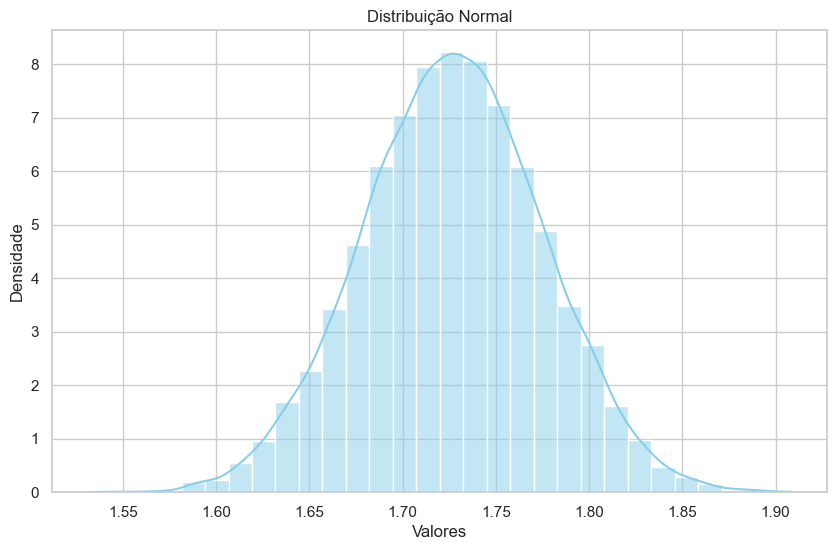

In [32]:
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6)) 
sns.histplot(df['Altura(m)'], kde=True, color="skyblue", bins=30, stat="density")
plt.title('Distribuição Normal')
plt.xlabel('Valores')
plt.ylabel('Densidade')
plt.show()

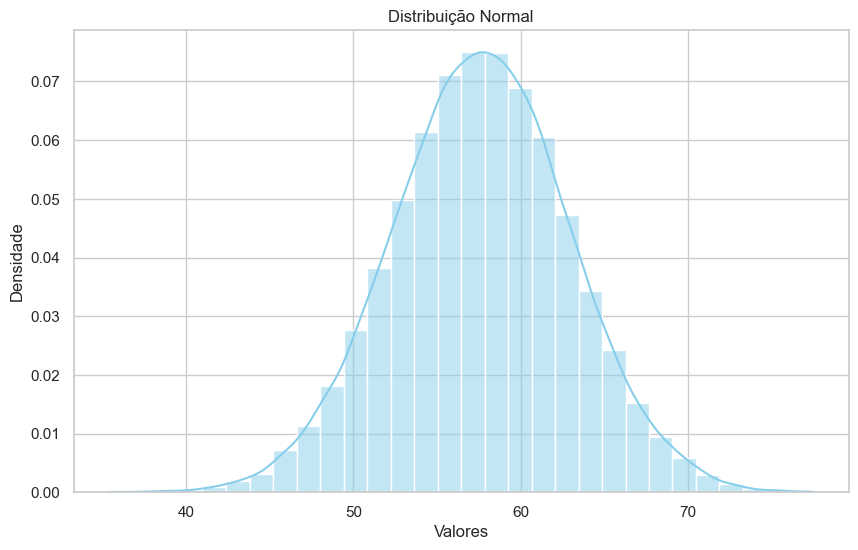

In [33]:
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))  
sns.histplot(df['Peso(kg)'], kde=True, color="skyblue", bins=30, stat="density")
plt.title("Distribuição Normal")
plt.xlabel("Valores")
plt.ylabel("Densidade")
plt.show()

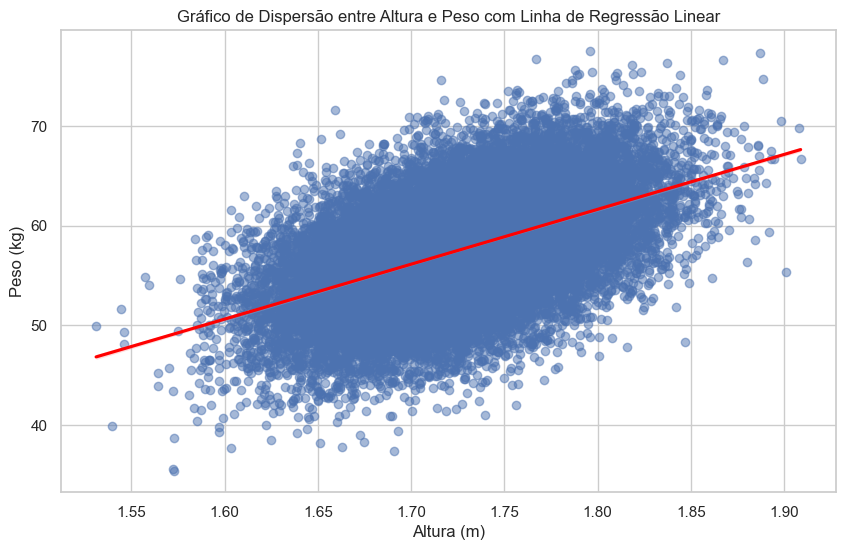

In [34]:
plt.figure(figsize=(10, 6)) 
sns.regplot(x='Altura(m)', y='Peso(kg)', data=df, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title("Gráfico de Dispersão entre Altura e Peso com Linha de Regressão Linear")
plt.xlabel("Altura (m)")
plt.ylabel("Peso (kg)")
plt.show()

ESTIMATIVA DE IDADE COM BASE NO PESO E ALTURA DO INDIVIDUO 

In [37]:
!pip install scikit-learn

  Using cached scikit_learn-1.6.1-cp39-cp39-macosx_12_0_arm64.whl (11.1 MB)
  Using cached scipy-1.13.1-cp39-cp39-macosx_12_0_arm64.whl (30.3 MB)
  Using cached threadpoolctl-3.7.0-py3-none-any.whl (26 kB)
  Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
You should consider upgrading via the '/Users/cristinasaraivafigueiredo/Aula_Banco_Dados/venv/bin/python3 -m pip install --upgrade pip' command.


In [38]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [41]:
# 1. Seleciona as variáveis
X = df[['Peso(kg)', 'Altura(m)']] # Ajuste para os nomes exatos das suas colunas
y = df['Index']

# 2. Divide em dados de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Treina o modelo de Regressão Linear
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# 4. Avalia a precisão
y_pred = modelo.predict(X_test)
print(f"R² Score: {r2_score(y_test, y_pred):.2f}")

R² Score: 0.00


In [43]:
print(df.columns.tolist())

['Index', 'Altura(m)', 'Peso(kg)']


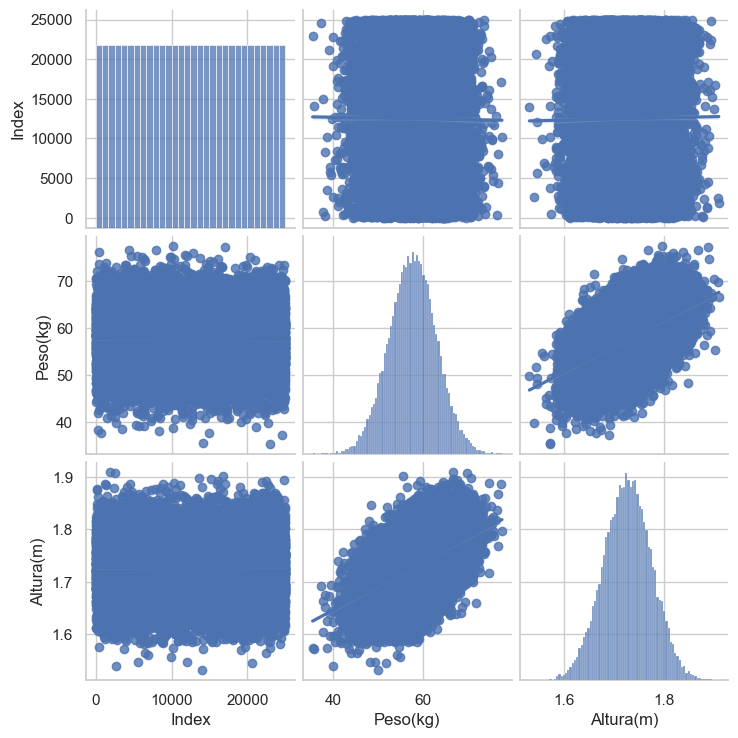

              Index  Peso(kg)  Altura(m)
Index      1.000000 -0.007257   0.009626
Peso(kg)  -0.007257  1.000000   0.502859
Altura(m)  0.009626  0.502859   1.000000


In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

# Gera um gráfico de dispersão com linha de tendência
sns.pairplot(df[['Index', 'Peso(kg)', 'Altura(m)']], kind='reg')
plt.show()

# Ou exibe a matriz de correlação rápida
print(df[['Index', 'Peso(kg)', 'Altura(m)']].corr())